In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from ptyrad.analysis import Analyzer
from matplotlib.gridspec import GridSpec
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.colors import Normalize
import seaborn as sns

In [2]:
from tifffile import imread, imwrite

In [3]:
from skimage.filters import gaussian, window
from skimage.feature import peak_local_max, match_template
from scipy.ndimage import median_filter, rotate,shift
from skimage.transform import AffineTransform, warp


In [4]:
import atomap.api as am

/Users/nihy/Desktop/stem_analysis/.venv/lib/python3.12/site-packages/hyperspy/misc/_utils.py:1590: VisibleDeprecationWarning: Importing `LazyComplexSignal1D` from `hyperspy._signals.complex_signal1d` is deprecated and will be removed in the HyperSpy 3.0 release. Import it from `hyperspy.signals` instead.
  warnings.warn(
/Users/nihy/Desktop/stem_analysis/.venv/lib/python3.12/site-packages/hyperspy/misc/_utils.py:1590: VisibleDeprecationWarning: Importing `LazySignal1D` from `hyperspy._signals.signal1d` is deprecated and will be removed in the HyperSpy 3.0 release. Import it from `hyperspy.signals` instead.
  warnings.warn(
/Users/nihy/Desktop/stem_analysis/.venv/lib/python3.12/site-packages/hyperspy/misc/_utils.py:1590: VisibleDeprecationWarning: Importing `LazySignal1D` from `hyperspy._signals.signal1d` is deprecated and will be removed in the HyperSpy 3.0 release. Import it from `hyperspy.signals` instead.
  warnings.warn(


In [5]:
import PyQt5 

In [6]:
%matplotlib widget

# Load Data

In [7]:
work_dir = '/Users/nihy/Desktop/Working Data/DRX/Zone 211/Shear Corrected/Analysis'

In [8]:
ptyrad_file = os.path.join(work_dir, "object_phase_crop.tif")

In [9]:
img_stack = imread(ptyrad_file)
img_stack.shape

(26, 359, 359)

In [29]:
dx, dy, dz = 0.01277, 0.01277, 1 # in nm

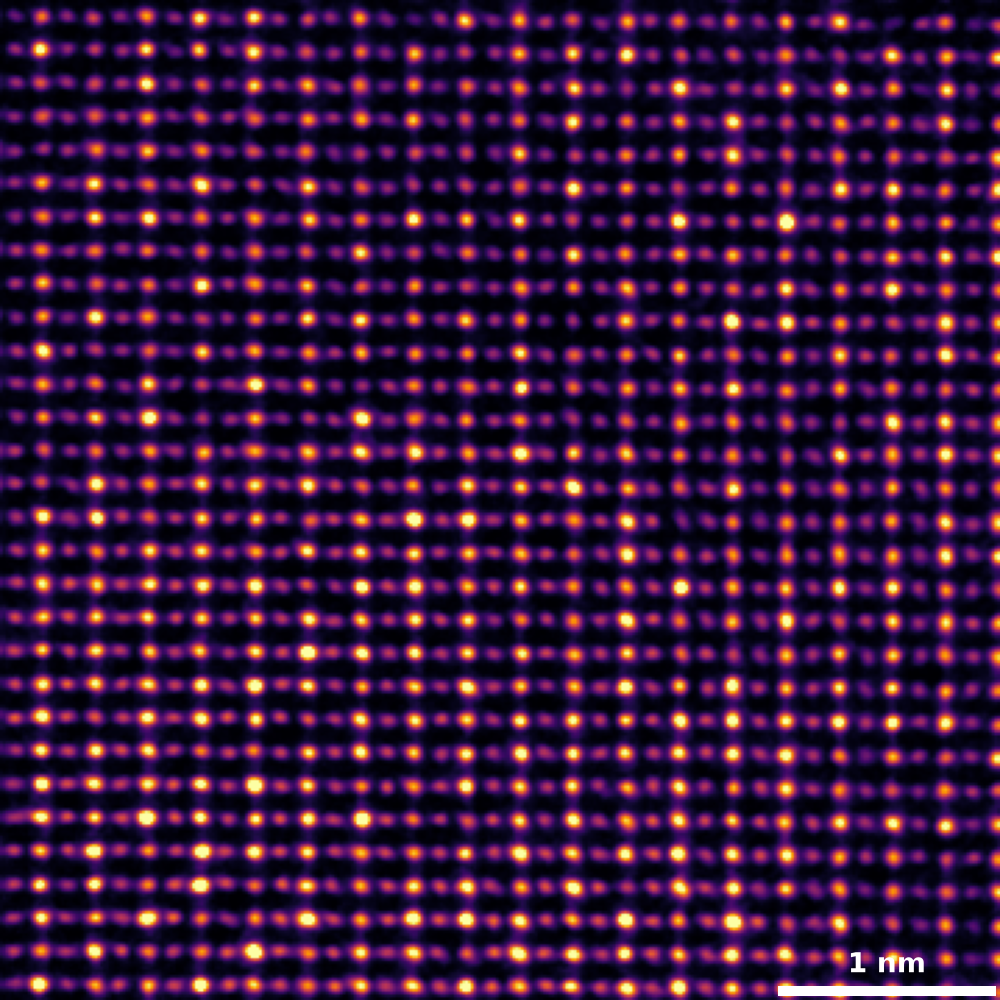

In [30]:
plt.figure(figsize = (10,10))
plt.subplots_adjust(0, 0, 1, 1)
plt.imshow(img_stack.sum(0), cmap='inferno',vmin = 0,vmax = np.pi)
ax = plt.gca()
sbar = ScaleBar(
    dx,
    'nm',
    dimension = "si-length",
    location = 'lower right',
    fixed_value = 1,
    frameon = False,
    color = 'w',
    scale_loc = 'top',
    font_properties = {'size': 20, 'weight': 'bold'}
)
ax.add_artist(sbar)
ax.axis('off')

plt.savefig(os.path.join(work_dir, "ptyrad_sum.svg"), dpi = 300, bbox_inches = 'tight', pad_inches = 0)

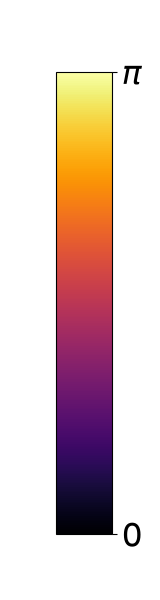

In [14]:
norm = Normalize(vmin=0, vmax=np.pi)
sm = plt.cm.ScalarMappable(norm=norm, cmap="inferno")
sm.set_array([])

fig, cax = plt.subplots(figsize=(1.6, 6))
fig.subplots_adjust(left=0.35, right=0.7)

cbar = fig.colorbar(sm, cax=cax)
cax.set_yticks([0, np.pi])
cax.set_yticklabels([0, r"$\pi$"], fontsize=24)

fig.savefig(
   os.path.join(work_dir, "standalone_colorbar.svg"),
   dpi=300,
   bbox_inches="tight",
   transparent=True,
)
plt.show()

# FFT

In [31]:
dq = 1/(img_stack.shape[1]*dx) # in 1/nm
dq

0.21812962571137523

In [32]:
w = window('hann', img_stack.shape)

In [33]:
fft_3d_abs = np.abs(np.fft.fftshift(np.fft.fftn(img_stack*w)))
fft_3d_abs.shape

(26, 359, 359)

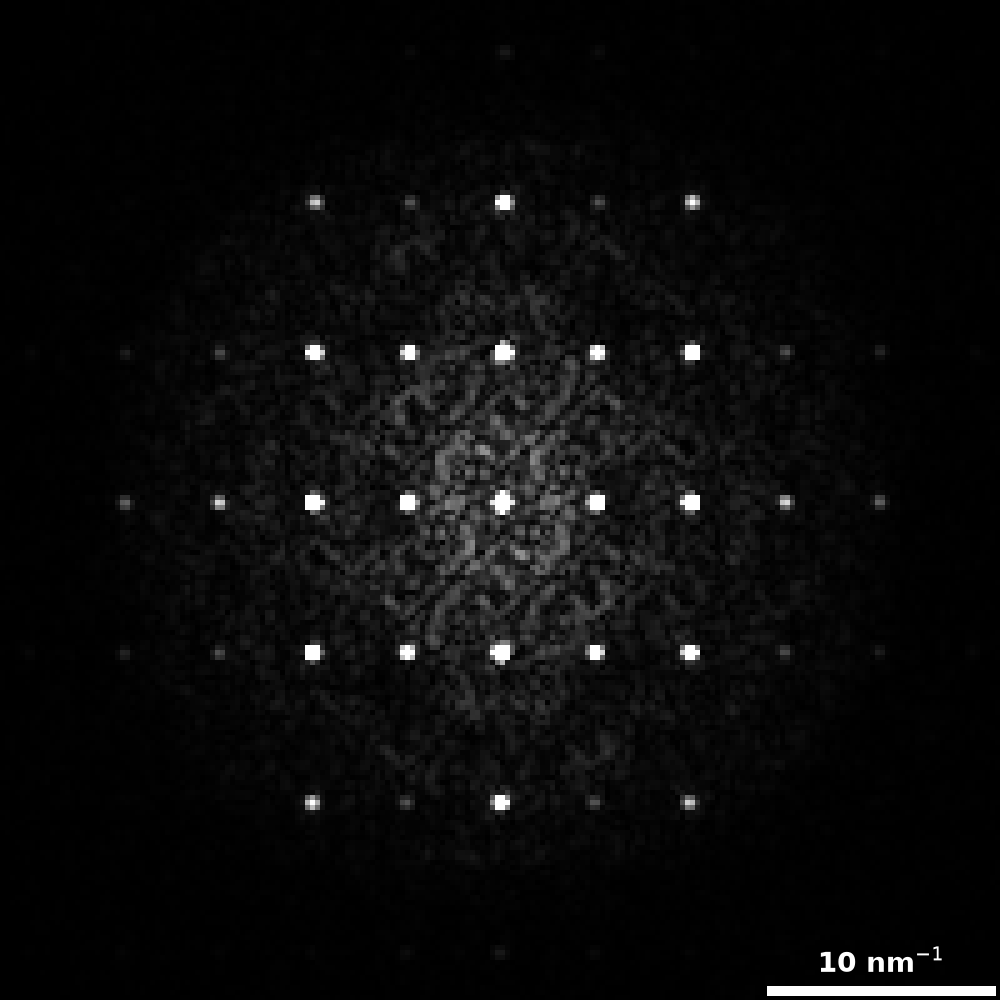

In [34]:
plt.figure(figsize = (10,10))
plt.subplots_adjust(0, 0, 1, 1)
plt.imshow(fft_3d_abs[26//2, 359//2 - 100:359//2+100, 359//2 - 100:359//2+100], cmap='gray', vmax = 600)
ax = plt.gca()
sbar = ScaleBar(
    dq,
    '1/nm',
    dimension = "si-length-reciprocal",
    location = 'lower right',
    fixed_value = 10,
    frameon = False,
    color = 'w',
    scale_loc = 'top',
    font_properties = {'size': 20, 'weight': 'bold'}
)
ax.add_artist(sbar)
ax.axis("off")
plt.savefig(os.path.join(work_dir, "ptyrad_fft.svg"), dpi = 300, bbox_inches = 'tight', pad_inches = 0)

# Find Lattice Points by a combined routine of template matching and lattice fitting

# Template matching

In [57]:
template = img_stack.max(0)[156:169, 253:273]

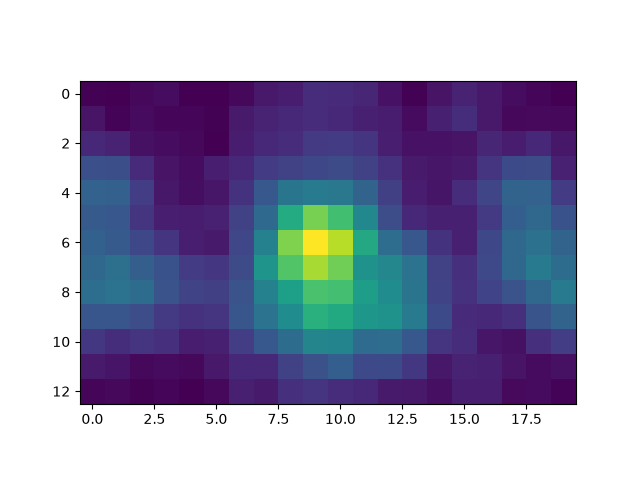

In [58]:
plt.figure()
plt.imshow(template)

In [59]:
matched = match_template(img_stack.sum(0), template, pad_input=True)

In [60]:
peaks = peak_local_max(matched, min_distance=7, threshold_abs=0.6)

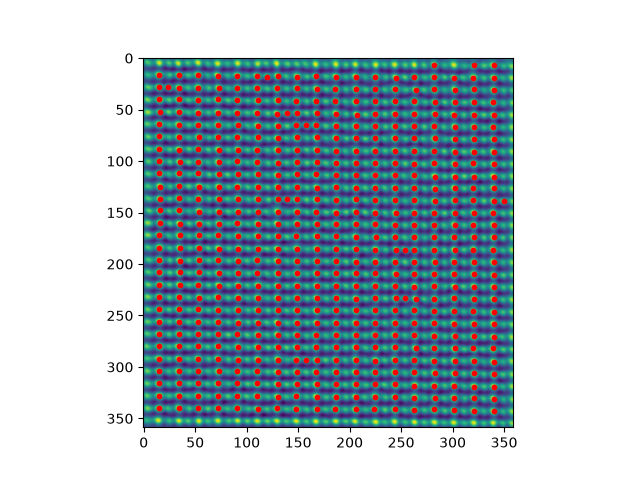

In [61]:
plt.figure()
plt.imshow(matched)
plt.scatter(peaks[:, 1], peaks[:, 0], color='r', s=10)

# Atomap Lattice Fitting

In [62]:
import hyperspy.api as hs

In [63]:
matched_hs = hs.signals.Signal2D(matched)

In [64]:
s_peaks = am.get_feature_separation(matched_hs, separation_range=(2, 20), show_progressbar=False)
s_peaks.plot()

In [65]:
lattice_positions = am.get_atom_positions(matched_hs, separation=8, threshold_rel=0.5)

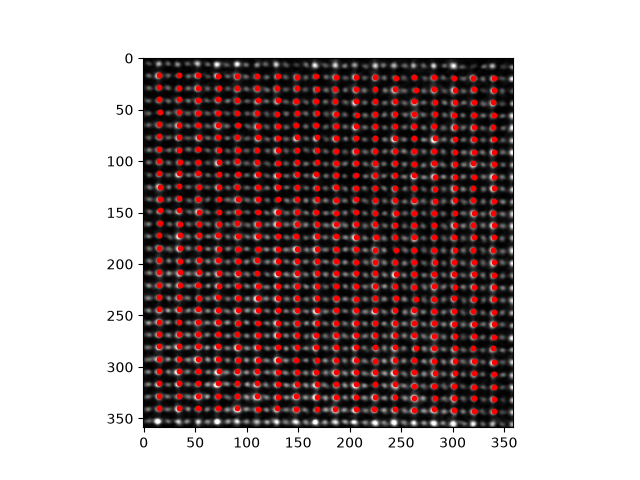

In [66]:
plt.figure()
plt.imshow(img_stack.sum(0), cmap='gray', vmin = 0, vmax = np.pi)
plt.scatter(lattice_positions[:, 0], lattice_positions[:, 1], color='r', s=10)

In [72]:
cation_positions = lattice_positions + [0, 0]
anion_positions = lattice_positions + [10, 0]

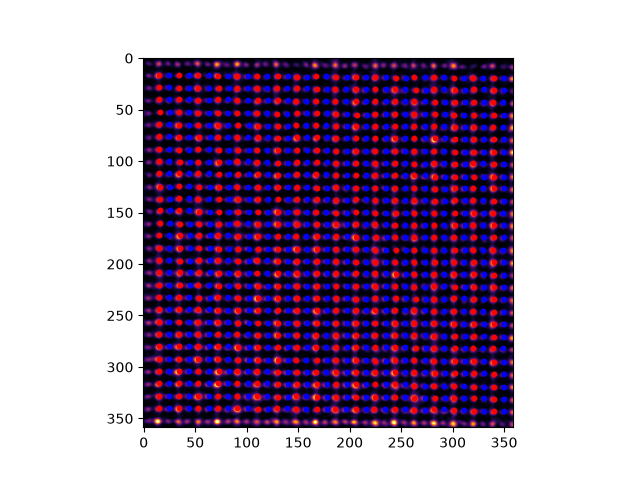

In [73]:
plt.figure()
plt.imshow(img_stack.sum(0), cmap='inferno', vmax = 4, vmin = 0)
plt.scatter(cation_positions[:, 0], cation_positions[:, 1], color='r', s=10)
plt.scatter(anion_positions[:, 0], anion_positions[:, 1], color='b', s=10)

In [74]:
sublattice_cation = am.Sublattice(cation_positions, image = img_stack.max(0))
sublattice_anion = am.Sublattice(anion_positions, image = img_stack.sum(0))

In [75]:
sublattice_cation.find_nearest_neighbors()
sublattice_cation.refine_atom_positions_using_center_of_mass()
sublattice_cation.refine_atom_positions_using_2d_gaussian()

Gaussian fitting: 100%|██████████| 504/504 [00:01<00:00, 370.56it/s]


In [76]:
sublattice_anion.find_nearest_neighbors()
sublattice_anion.refine_atom_positions_using_center_of_mass()
sublattice_anion.refine_atom_positions_using_2d_gaussian()

Gaussian fitting: 100%|██████████| 504/504 [00:01<00:00, 388.18it/s]


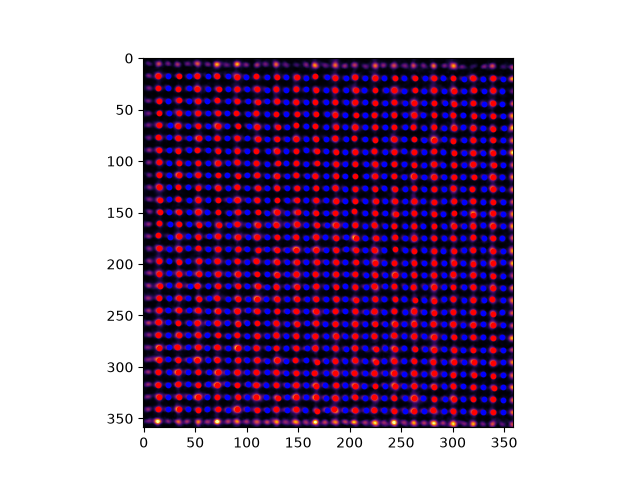

In [77]:
plt.figure()
plt.imshow(img_stack.sum(0), cmap='inferno', vmax = 4, vmin = 0)
plt.scatter(sublattice_cation.atom_positions[:, 0], sublattice_cation.atom_positions[:, 1], color='r', s=10)
plt.scatter(sublattice_anion.atom_positions[:, 0], sublattice_anion.atom_positions[:, 1], color='b', s=10)

## Save Intermediate Result

In [78]:
sum_phase_lattice = am.Atom_Lattice(image=img_stack.sum(0), name='sum phase', sublattice_list=[sublattice_cation, sublattice_anion])

In [79]:
sum_phase_lattice.save(os.path.join(work_dir,"sum_phase_lattice.hdf5"), overwrite=True)

# Fit Layer-by-Layer anion positions
Using Anion because of less variations of intensities

In [80]:
z = img_stack.shape[0]
z

26

In [82]:
slice_range = np.arange(0, z)
slice_range.shape

(26,)

In [83]:
sublattice_anion_layer_by_layer = []
for i in slice_range:
    s_anion = am.Sublattice(sublattice_anion.atom_positions, image = img_stack[i])
    s_anion.find_nearest_neighbors()
    s_anion.refine_atom_positions_using_center_of_mass()
    #s_anion.refine_atom_positions_using_2d_gaussian()
    sublattice_anion_layer_by_layer.append(s_anion)

Center of mass:   0%|          | 0/504 [00:00<?, ?it/s]/Users/nihy/Desktop/stem_analysis/.venv/lib/python3.12/site-packages/atomap/atom_finding_refining.py:604: RuntimeWarning: invalid value encountered in divide
  arr = arr / np.sum(arr, axis=(-1, -2))
Center of mass: 100%|██████████| 504/504 [00:00<00:00, 54817.55it/s]


In [84]:
sublattice_cation_layer_by_layer = []
for i in slice_range:
    s_cation = am.Sublattice(cation_positions, image = img_stack[i])
    s_cation.find_nearest_neighbors()
    s_cation.refine_atom_positions_using_center_of_mass()
    #s_cation.refine_atom_positions_using_2d_gaussian()
    sublattice_cation_layer_by_layer.append(s_cation)

Center of mass: 100%|██████████| 504/504 [00:00<00:00, 58659.97it/s]


In [85]:
sublattice_anion_layer_by_layer_pos = np.array([s_anion.atom_positions for s_anion in sublattice_anion_layer_by_layer])
sublattice_anion_layer_by_layer_pos.shape

(26, 504, 2)

In [86]:
sublattice_cation_layer_by_layer_pos = np.array([s_cation.atom_positions for s_cation in sublattice_cation_layer_by_layer])
sublattice_cation_layer_by_layer_pos.shape

(26, 504, 2)

In [87]:
sublattice_anion_layer_by_layer_pos_shift = sublattice_anion_layer_by_layer_pos - np.mean(sublattice_anion_layer_by_layer_pos, axis = 0, keepdims = True)
sublattice_cation_layer_by_layer_pos_shift = sublattice_cation_layer_by_layer_pos - np.mean(sublattice_cation_layer_by_layer_pos, axis = 0, keepdims = True)

In [94]:
np.nanmedian(sublattice_anion_layer_by_layer_pos_shift, axis=1)

array([[-0.09988194, -0.01343165],
       [ 0.01504905,  0.0484515 ],
       [ 0.22717609,  0.16612146],
       [ 0.34754504,  0.1655029 ],
       [ 0.36146903,  0.15282971],
       [ 0.33514314,  0.12539821],
       [ 0.28647644,  0.18677219],
       [ 0.17989373,  0.32963438],
       [ 0.16724341,  0.35997335],
       [ 0.21555171,  0.30841264],
       [ 0.20892637,  0.2631688 ],
       [ 0.02881483,  0.21775639],
       [-0.16842785,  0.07112973],
       [-0.15014338, -0.08945483],
       [-0.1890103 , -0.22935419],
       [-0.23192326, -0.26501003],
       [-0.27015098, -0.3142615 ],
       [-0.3532559 , -0.39643389],
       [-0.40510546, -0.44520178],
       [-0.37011783, -0.45691694],
       [-0.38796253, -0.32951955],
       [-0.2669406 , -0.22827882],
       [ 0.1059216 , -0.02788914],
       [ 0.13645029,  0.10142555],
       [ 0.16885441,  0.19502461],
       [ 0.10638439,  0.18206861]])

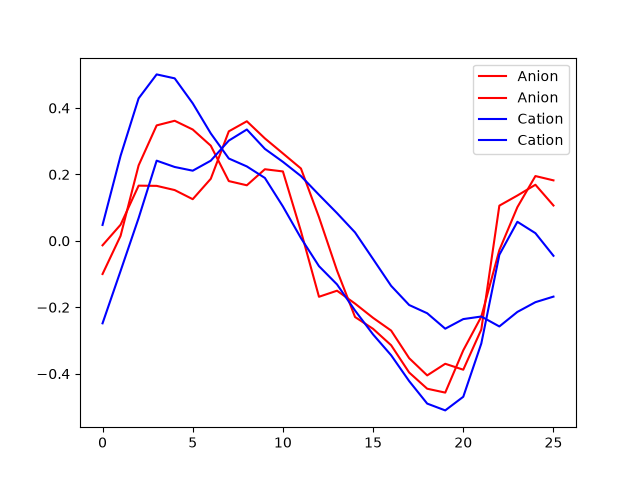

In [96]:
plt.figure()
plt.plot(np.nanmedian(sublattice_anion_layer_by_layer_pos_shift, axis=1), c ='r', label = 'Anion')
plt.plot(np.nanmedian(sublattice_cation_layer_by_layer_pos_shift, axis=1), c ='b', label = 'Cation')
plt.legend()

In [49]:
# Shift image due to the mistilt

In [105]:
img_stack_shifted = np.zeros_like(img_stack)
for i in slice_range:
    img_stack_shifted[i] = shift(img_stack[i], shift = -np.nanmedian(sublattice_cation_layer_by_layer_pos_shift, axis=1)[i][::-1], order = 1)
img_stack_shifted.min(), img_stack_shifted.max()    

(np.float32(0.0), np.float32(0.5328937))

In [106]:
imwrite(os.path.join(work_dir,"object_phase_cropped_aligned_0_26.tif"), img_stack_shifted.astype(np.float32))

In [107]:
sum_phase_aligned = np.nansum(img_stack_shifted, axis=0)

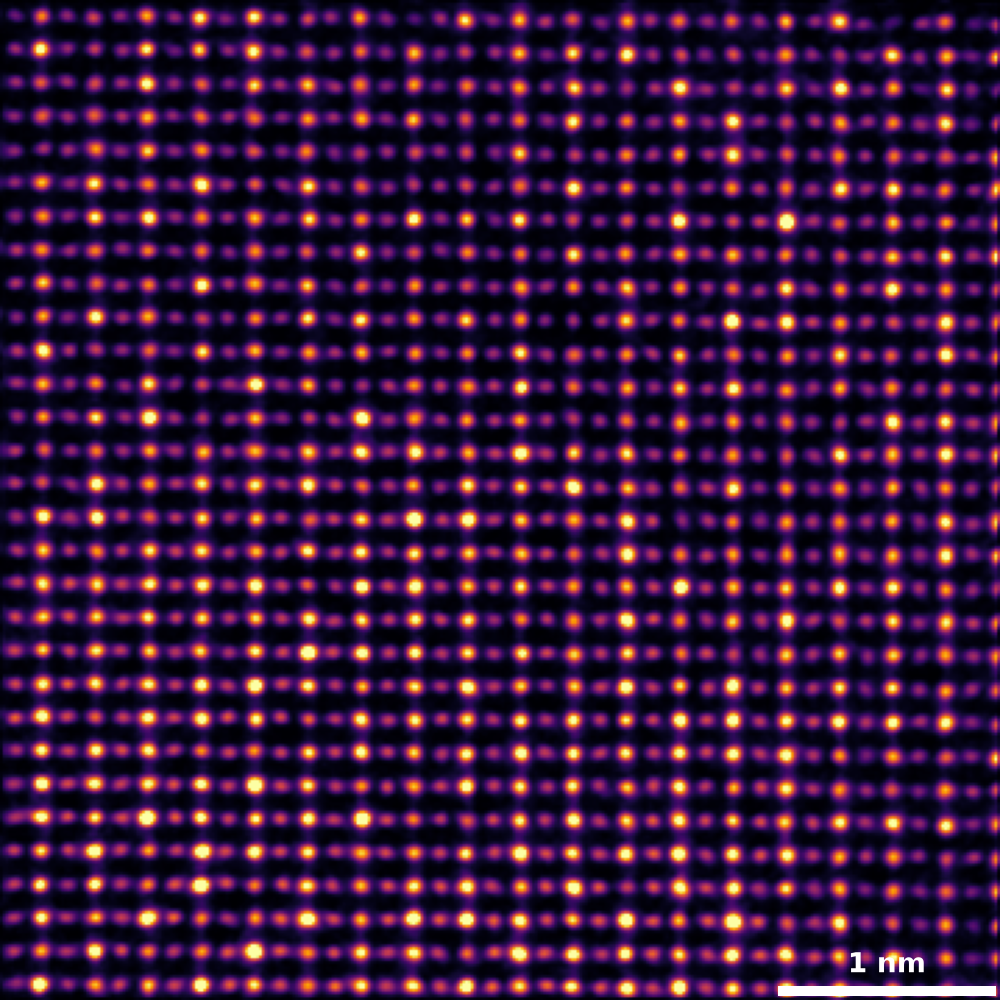

In [108]:
plt.figure(figsize = (10,10))
plt.subplots_adjust(0, 0, 1, 1)
plt.imshow(sum_phase_aligned, cmap='inferno',vmin = 0,vmax = np.pi)
ax = plt.gca()
sbar = ScaleBar(
    dx,
    'nm',
    dimension = "si-length",
    location = 'lower right',
    fixed_value = 1,
    frameon = False,
    color = 'w',
    scale_loc = 'top',
    font_properties = {'size': 20, 'weight': 'bold'}
)
ax.add_artist(sbar)
ax.axis('off')

plt.savefig(os.path.join(work_dir, "ptyrad_sum_aligned.svg"), dpi = 300, bbox_inches = 'tight', pad_inches = 0)

In [111]:
fft_3d_abs = np.abs(np.fft.fftshift(np.fft.fftn(img_stack_shifted*w)))
fft_3d_abs.shape

(26, 359, 359)

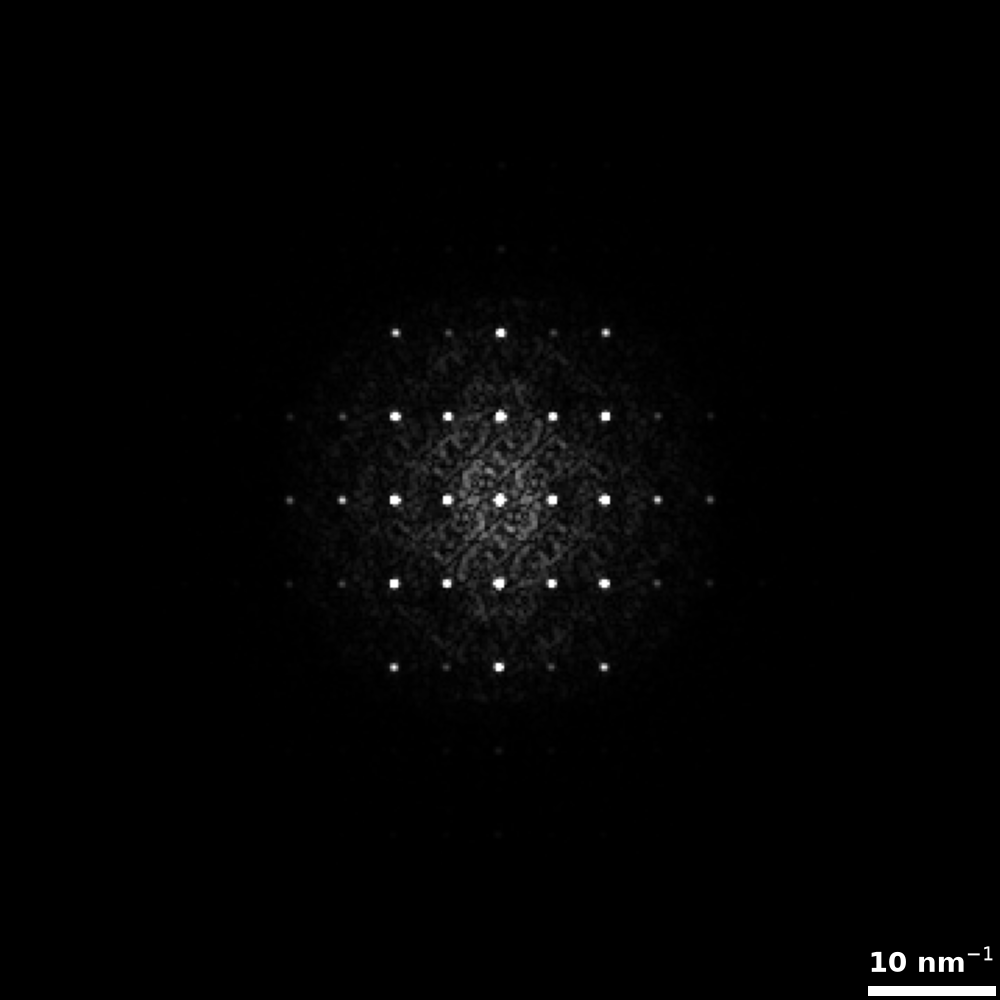

In [112]:
plt.figure(figsize = (10,10))
plt.subplots_adjust(0, 0, 1, 1)
plt.imshow(fft_3d_abs[z//2], cmap='gray', vmax = 600)
ax = plt.gca()
sbar = ScaleBar(
    dq,
    '1/nm',
    dimension = "si-length-reciprocal",
    location = 'lower right',
    fixed_value = 10,
    frameon = False,
    color = 'w',
    scale_loc = 'top',
    font_properties = {'size': 20, 'weight': 'bold'}
)
ax.add_artist(sbar)
ax.axis("off")
plt.savefig(os.path.join(work_dir, "ptyrad_fft_aligned.svg"), dpi = 300, bbox_inches = 'tight', pad_inches = 0)

In [58]:
from matplotlib.animation import FuncAnimation, PillowWriter

fig_animation, ax_animation = plt.subplots(figsize=(6, 6))
im_animation = ax_animation.imshow(
    img_stack_shifted[0],
    cmap="inferno",
    vmin=0,
    vmax=np.percentile(img_stack_shifted, 99.5),
)
ax_animation.axis("off")
title_animation = ax_animation.set_title("Slice 0", color="white")

def update_animation(frame):
    im_animation.set_data(img_stack_shifted[frame])
    title_animation.set_text(f"Slice {frame}")
    return im_animation, title_animation

animation = FuncAnimation(
    fig_animation,
    update_animation,
    frames=img_stack_shifted.shape[0],
    interval=150,
    blit=True,
)

animation_path = os.path.join(work_dir, "object_phase_cropped_aligned_0_30.gif")
animation.save(
    animation_path,
    writer=PillowWriter(fps=7), 
    dpi = 300
)

plt.close(fig_animation)
print(f"Saved animation to: {animation_path}")

Saved animation to: /Users/nihy/Desktop/Working Data/EuAl4/Cryo Zone 001/11/1/object_phase_cropped_aligned_0_60.gif
